In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd

sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
#mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
mnt_pth = '/home/ronja/projects/MeltSensitivity/' #mount path
pth_ismip6hack= mnt_pth + 'ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']


In [3]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]

for exp in expnames:
    lst = glob.glob(pth_ismip6hack+f'{exp}/thermalforcing/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        #if model in removeFileID:
        #    continue
        if 'AIS' in name:   # exclude a previous PISM_PIK calculation
        #else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
#for i in range(1,19):
#    df['sector_'+str(i)]=0
df['vals2100']=0
df['vals2200']=0
df['vals2300']=0

df_org = df.copy()

In [4]:
df_org

,Experiment,Model,Path,vals2100,vals2200,vals2300
0,expAE02,DC_ISSM,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
1,expAE02,DOE_MALI_1,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
2,expAE02,DOE_MALI_2,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
3,expAE02,DOE_MALI_3,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
4,expAE02,IGE_ElmerIce,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
...,...,...,...,...,...,...
167,expAE05,VUW_PISM2,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
168,expAE05,VUW_PISM2_s1,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
169,expAE05,VUW_PISM2_s2,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0
170,expAE05,VUW_PISM2_s3,/home/ronja/projects/MeltSensitivity/ComputedS...,0,0,0


In [5]:
renamer = {}
renamer['DOE_MALI_1']='DOE_MALI_4km'
renamer['DOE_MALI_2']='DOE_MALI_8km_Ant95'
renamer['DOE_MALI_3']='DOE_MALI_8km_AntMean'     

In [18]:
np.arange(2015, 2300)

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
       2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
       2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058,
       2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069,
       2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080,
       2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091,
       2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100, 2101, 2102,
       2103, 2104, 2105, 2106, 2107, 2108, 2109, 2110, 2111, 2112, 2113,
       2114, 2115, 2116, 2117, 2118, 2119, 2120, 2121, 2122, 2123, 2124,
       2125, 2126, 2127, 2128, 2129, 2130, 2131, 2132, 2133, 2134, 2135,
       2136, 2137, 2138, 2139, 2140, 2141, 2142, 2143, 2144, 2145, 2146,
       2147, 2148, 2149, 2150, 2151, 2152, 2153, 2154, 2155, 2156, 2157,
       2158, 2159, 2160, 2161, 2162, 2163, 2164, 21

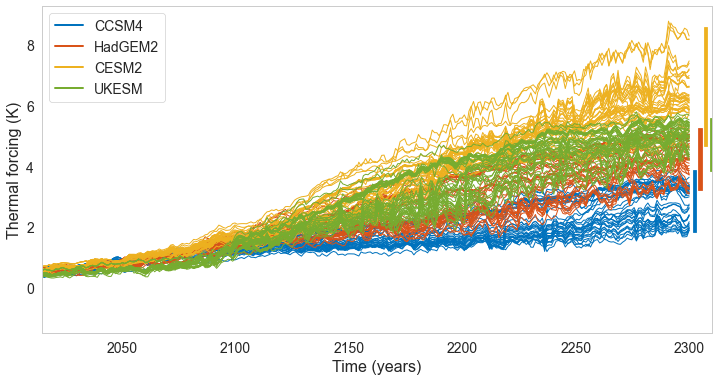

In [31]:
time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]


expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
valuesend_dict2 = {expname: [] for expname in expnames}

dic_all = {}

colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

f,ax2 = plt.subplots(1,1, figsize = (12,6),sharex =True)


for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    
    dfp = df_org[df_org.Experiment == expname].reset_index(drop = True)
    
    for i in  range(dfp.shape[0]):
        
        filename = dfp['Path'][i]
        #print(filename)
        #if 'DOE_MALI' in filename:
        
        d = xr.open_dataset(filename,decode_times=False )
        data = d.thermalforcing.values #* 365.25 * 24 * 3600 / 10**12
        
        valuesend_dict[expname].append(data[time.size-10])
        plt.plot(np.linspace(2015,2300,d.time.size-3), data[:d.time.size-3], linewidth=1, color=colors[iexp, :])
        #            df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
        #            df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
        #            df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
      
                
        
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    plt.fill(x, y, [-1, -1, -1, -1], color=colors[iexp, :], edgecolor=colors[iexp, :])

#ax.set_ylim([0, 2.5 * 10**4])
ax2.set_xlabel('Time (years)', fontsize=16)
ax2.set_ylabel('Thermal forcing (K)', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax2.legend(handles=legend_lines, loc='upper left', fontsize=14)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax2.set_xlim([2015, 2310])
# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax2.tick_params(labelsize=14)
ax2.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax2.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
plt.savefig('Figures/ThermalForcing.png', format='png', bbox_inches='tight')
plt.savefig('Figures/ThermalForcing.pdf', format='pdf', bbox_inches='tight')
plt.show()       